# Composite: **oven-mitts (dark)** background + **americano cup-pour** + **split-cookie cookie**

Builds a 3-way 4D composite where:
- **Background**: `oven-mitts_dark` (s=0.25 dimmed kitchen) with the oven mitts **removed** via classifier-based DELETE mask.
- **Foreground 1**: cup + pour from `misc_americano` (uses the existing pseudo `ids16-18_q0.95_trimdef_pp` insert mask).
- **Foreground 2**: cookie from `split-cookie` (we invert the existing `split-cookie.pt` DELETE mask to get the cookie itself as an insert mask).

Each foreground keeps its own **per-Gaussian deformation network**, so the cup-pour and the cookie-break dynamics survive into the rendered video AND into the exported composite PLY/mask consumed by the harmonization pipeline (`pipeline/render_composite_harmonized_motion_video.py` with `--composite_mode foreground_moves`).

## Prerequisites
1. `train_4dgs.py` finished for `oven-mitts` ✅ (already done).
2. Dark variant: `output/hypernerf/oven-mitts_dark/point_cloud/iteration_14000/scene_point_cloud.ply` ✅ (already done).
3. IE training for `oven-mitts` (so `classifier.pt`+`mlp.pt` exist under `oven-mitts/point_cloud/iteration_14000/`):
   ```bash
   bash prepare_pseudo_label.sh ./data/hypernerf/oven-mitts 0
   CUDA_VISIBLE_DEVICES=0 python train_ie.py -s ./data/hypernerf/oven-mitts/ -m ./output/hypernerf/oven-mitts/ --configs arguments/hypernerf/default.py
   cp output/hypernerf/oven-mitts/point_cloud/iteration_14000/{classifier,mlp}.pt output/hypernerf/oven-mitts_dark/point_cloud/iteration_14000/  # mirror to dark scene for masking
   ```
4. The mitts removal cells will detect missing `classifier.pt` and skip cleanly with instructions.

## Tuning workflow
1. Run sections 0 → 5 to land at a single-frame composite preview.
2. Use the **interactive widgets** in section 6 to drag each FG into place. Sliders write back to globals (`motion_bias_*`, `rotation_bias_*`, `scales_bias_*`).
3. Re-run the preview cell at a few different `VIEW_IDX` values (and timestamps) to verify alignment from multiple angles.
4. Run section 7 to render the full mp4. Section 8 exports the composite PLY + mask for harmonization.

## 0. Imports + helpers

In [32]:
import os, sys, time, gc, glob
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import torch
import numpy as np
from tqdm import tqdm
from argparse import ArgumentParser
from matplotlib import pyplot as plt
import imageio.v2 as imageio
import mmcv

from arguments import ModelParams, PipelineParams, ModelHiddenParams
from scene import Scene, GaussianModel
from gaussian_renderer import render as render_feature
from gaussian_renderer import render_contrastive_feature, render_segmentation
from utils.segment_utils import get_combined_args, visualize_obj, to8b
from utils.params_utils import merge_hparams
from utils.transform_utils_torch import init_dynamic_gaussians, render as render_compose, transform

%load_ext autoreload
%autoreload 2
print('Imports OK')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports OK


In [33]:
def load_feature_gaussians(model_path, cfg_path='./arguments/hypernerf/default.py'):
    """Load a scene in `feature` mode so we can access `_mlp` and `_classifier`.
    Requires `classifier.pt` + `mlp.pt` in the iteration folder (produced by `train_ie.py`).
    """
    parser = ArgumentParser()
    model_p = ModelParams(parser, sentinel=True)
    pipeline_p = PipelineParams(parser)
    hp = ModelHiddenParams(parser)
    parser.add_argument('--iteration', default=-1, type=int)
    parser.add_argument('--mode', default='feature')
    parser.add_argument('--configs', type=str, default=cfg_path)

    args = get_combined_args(parser, model_path, 'feature')
    config = mmcv.Config.fromfile(args.configs)
    args = merge_hparams(args, config)
    dataset = model_p.extract(args); hyperparam = hp.extract(args); pipeline = pipeline_p.extract(args)
    dataset.object_masks = True
    dataset.need_gt_masks = True

    g = GaussianModel(dataset.sh_degree, 'feature', hyperparam, dataset.feature_dim)
    sc = Scene(dataset, g, load_iteration=args.iteration, mode='feature')
    bg_color = torch.tensor([1,1,1] if dataset.white_background else [0,0,0], dtype=torch.float32, device='cuda')
    bg_feature = torch.zeros(dataset.feature_dim, dtype=torch.float32, device='cuda')
    train_cams = list(sc.getTrainCameras()); video_cams = list(sc.getVideoCameras())
    print(f'  feature mode: {model_path} | train={len(train_cams)} video={len(video_cams)} N_gauss={g.get_xyz.shape[0]}')
    return g, sc, pipeline, bg_color, bg_feature, train_cams, video_cams


def load_scene_for_composite(model_path, cfg_path='./arguments/hypernerf/default.py'):
    """Load a scene in `scene` mode (deformation network active) for compositing.
    Returns (gaussians, scene, background) like in composite_misc_americano_torchocolate."""
    parser = ArgumentParser()
    model_p = ModelParams(parser, sentinel=True)
    hp = ModelHiddenParams(parser)
    parser.add_argument('--iteration', default=-1, type=int)
    parser.add_argument('--configs', type=str, default=cfg_path)
    args = get_combined_args(parser, model_path, 'scene')
    config = mmcv.Config.fromfile(args.configs)
    args = merge_hparams(args, config)
    args.object_masks = False; args.need_gt_masks = False
    g, sc, bg = init_dynamic_gaussians(model_p.extract(args), hp.extract(args), args.iteration)
    print(f'  scene mode:   {model_path} | N_gauss={g.get_xyz.shape[0]}')
    return g, sc, bg

print('helpers OK')

helpers OK


## 1. Paths

All scenes share `arguments/hypernerf/default.py`. The dark BG (s=0.25) is the visible background; the IE classifier still lives in the original `oven-mitts/` checkpoint, so we point the FEATURE-MODE load there for mask generation, but use `oven-mitts_dark/` for the actual composite render.

If you want a brighter BG, flip `BG_MODEL_RENDER` between `oven-mitts_dark` (s=0.25), an intermediate dim version you generated with `scripts/darken_sh.py`, or the original `oven-mitts`.

In [34]:
# ── Models ──
BG_MODEL_IE     = './output/hypernerf/oven-mitts'        # has (or will have) classifier.pt+mlp.pt for mask gen
BG_MODEL_RENDER = './output/hypernerf/oven-mitts_dark'   # actual BG used in the composite render (s=0.25)
FG1_MODEL       = './output/hypernerf/misc_americano'    # cup + pour
FG2_MODEL       = './output/hypernerf/split-cookie'      # cookie that breaks
CFG_PATH        = './arguments/hypernerf/default.py'

EXPORT_TAG = 'v01'           # bump to keep multiple iterations side-by-side
RUN_TAG = f'oven_mitts_dark_americano_cookie_{EXPORT_TAG}'
RENDER_DIR = f'./output/composite_{RUN_TAG}'
os.makedirs(RENDER_DIR, exist_ok=True)

# ── Mask paths ──
# (a) BG DELETE mask for oven-mitts. Will be generated below if missing.
OVEN_MASK_NAME  = f'oven-mitts_delete_mitts_{EXPORT_TAG}'
BG_MASK_PATH    = os.path.join(BG_MODEL_IE, 'segment_results', OVEN_MASK_NAME + '.pt')

# (b) FG1 INSERT mask for the americano cup+pour. We INVERT the existing `delete_mc0.8_q0.9.pt`
# DELETE mask, which captures the hand pouring espresso into a glass cup *without* bringing in the
# whole table/floor (~24k active per frame, no empty frames). The original pseudo `vote8_ff006_q095`
# masked only ~2900/frame and turned out to be mostly counter pixels — see scripts/compare_fg_masks.py.
# Switch this path if you want a different cup mask (also see scripts/compare_fg_masks.py for other options).
FG1_INVERT_FROM = os.path.join(FG1_MODEL, 'segment_results', 'misc_americano_delete_mc0.8_q0.9.pt')
FG1_MASK_PATH   = os.path.join(FG1_MODEL, 'segment_results', f'misc_americano_cup_pour_{EXPORT_TAG}.pt')

# (c) FG2 INSERT mask for the cookie + hands. Two-step build:
#   1. Invert the existing `split-cookie.pt` DELETE mask (True=cookie+hands+tablecloth).
#   2. Drop blue/white Gaussians (the checkered tablecloth) by per-Gaussian SH-DC colour
#      filtering, leaving only warm tones (cookie + skin). See scripts/filter_cookie_no_table.py.
FG2_INVERT_FROM       = os.path.join(FG2_MODEL, 'segment_results', 'split-cookie.pt')
FG2_MASK_INVERTED     = os.path.join(FG2_MODEL, 'segment_results', f'split-cookie_only_cookie_{EXPORT_TAG}.pt')
FG2_MASK_PATH         = os.path.join(FG2_MODEL, 'segment_results', f'split-cookie_cookie_hands_{EXPORT_TAG}.pt')

# ── Export targets (written under BG_MODEL_RENDER so harmonize runs against the dark scene) ──
EXPORT_PLY_PATH  = os.path.join(BG_MODEL_RENDER, 'point_cloud', 'iteration_14000', f'composite_oven_americano_cookie_{EXPORT_TAG}.ply')
EXPORT_MASK_PATH = os.path.join(BG_MODEL_RENDER, 'segment_results', f'composite_inserted_americano_cookie_{EXPORT_TAG}.pt')

for label, path, must_exist in [
    ('BG_MODEL_IE/cfg_args',       os.path.join(BG_MODEL_IE,     'cfg_args'), True),
    ('BG_MODEL_RENDER/cfg_args',   os.path.join(BG_MODEL_RENDER, 'cfg_args'), True),
    ('BG classifier.pt',           os.path.join(BG_MODEL_IE, 'point_cloud', 'iteration_14000', 'classifier.pt'), False),
    ('FG1 (americano) PLY',        os.path.join(FG1_MODEL,   'point_cloud', 'iteration_14000', 'scene_point_cloud.ply'), True),
    ('FG1 source mask (delete)',   FG1_INVERT_FROM, True),
    ('FG1 mask (cup+pour)',        FG1_MASK_PATH, False),
    ('FG2 (split-cookie) PLY',     os.path.join(FG2_MODEL,   'point_cloud', 'iteration_14000', 'scene_point_cloud.ply'), True),
    ('FG2 source mask (cookie)',   FG2_INVERT_FROM, True),
]:
    ok = os.path.exists(path)
    flag = '✓' if ok else ('✗ MISSING' if must_exist else '⚠ missing (will train/build)')
    print(f'  {flag} {label:30s} {path}')
    if must_exist and not ok:
        raise FileNotFoundError(path)

  ✓ BG_MODEL_IE/cfg_args           ./output/hypernerf/oven-mitts/cfg_args
  ✓ BG_MODEL_RENDER/cfg_args       ./output/hypernerf/oven-mitts_dark/cfg_args
  ✓ BG classifier.pt               ./output/hypernerf/oven-mitts/point_cloud/iteration_14000/classifier.pt
  ✓ FG1 (americano) PLY            ./output/hypernerf/misc_americano/point_cloud/iteration_14000/scene_point_cloud.ply
  ✓ FG1 source mask (delete)       ./output/hypernerf/misc_americano/segment_results/misc_americano_delete_mc0.8_q0.9.pt
  ✓ FG1 mask (cup+pour)            ./output/hypernerf/misc_americano/segment_results/misc_americano_cup_pour_v01.pt
  ✓ FG2 (split-cookie) PLY         ./output/hypernerf/split-cookie/point_cloud/iteration_14000/scene_point_cloud.ply
  ✓ FG2 source mask (cookie)       ./output/hypernerf/split-cookie/segment_results/split-cookie.pt


## 2. Build the FG INSERT masks (invert the matching DELETE masks)

Both `split-cookie.pt` and `misc_americano_delete_mc0.8_q0.9.pt` are DELETE-style tables where `True` means *keep this Gaussian on the BG* (i.e. it is **not** the object). We negate them to isolate the cookie / cup-pour. This is cheap (~ms) and idempotent.

In [35]:
def _invert_delete_mask(src_path, dst_path, label, note):
    if os.path.exists(dst_path):
        print(f'reuse existing {dst_path}')
        return
    src = torch.load(src_path, map_location='cpu')
    inverted = {
        'mask_table': (~src['mask_table']).bool().contiguous(),
        'time_map':   src.get('time_map', torch.linspace(0, 1, src['mask_table'].shape[0])),
        'inverted_from': os.path.basename(src_path),
        'note': note,
    }
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    torch.save(inverted, dst_path)
    counts = inverted['mask_table'].float().sum(dim=1).numpy()
    print(f'wrote {dst_path}  ({label}: per-frame  min={counts.min():.0f} mean={counts.mean():.0f} max={counts.max():.0f})')

_invert_delete_mask(FG1_INVERT_FROM, FG1_MASK_PATH, 'cup+pour',
    'True=cup+pour+pouring-hand, produced by inverting misc_americano_delete_mc0.8_q0.9.pt')
_invert_delete_mask(FG2_INVERT_FROM, FG2_MASK_INVERTED, 'cookie+hands+tablecloth',
    'True=cookie+hands+tablecloth, produced by inverting split-cookie.pt DELETE mask')

# Step 2 for FG2: colour-filter to drop the checkered tablecloth (blue/white Gaussians).
# The cookie scene has no per-id classifier, so we filter by per-Gaussian DC colour:
#   drop if (B > R+0.05 and B > G+0.05)  -> tablecloth blue
#        or (min(R,G,B) > 0.78)          -> tablecloth white
#        or (B > 0.55 and R<0.5 and G<0.5) -> blue-grey checker shadow
# Keeps warm-toned Gaussians (cookie crust + skin). Run scripts/filter_cookie_no_table.py to tune.
if not os.path.exists(FG2_MASK_PATH):
    from utils.sh_utils import SH2RGB
    inv = torch.load(FG2_MASK_INVERTED, map_location='cpu')
    # We need the SH DC features of g2 to compute colour. They're loaded later (in §4),
    # so we lazily reload the PLY just for the colour-filtering step here.
    from plyfile import PlyData
    ply = PlyData.read(os.path.join(FG2_MODEL, 'point_cloud', 'iteration_14000', 'scene_point_cloud.ply'))
    v = ply['vertex']
    fdc = np.stack([np.asarray(v['f_dc_0']), np.asarray(v['f_dc_1']), np.asarray(v['f_dc_2'])], axis=1).astype(np.float32)
    rgb = SH2RGB(torch.from_numpy(fdc)).clamp(0, 1).numpy()
    R, G, B = rgb[:, 0], rgb[:, 1], rgb[:, 2]
    drop = ((B > R + 0.05) & (B > G + 0.05)) | (np.minimum(np.minimum(R, G), B) > 0.78) | ((B > 0.55) & (R < 0.5) & (G < 0.5))
    keep = torch.from_numpy(~drop)
    new_table = inv['mask_table'] & keep.unsqueeze(0)
    out = {'mask_table': new_table.bool().contiguous(),
           'time_map':  inv.get('time_map', torch.linspace(0, 1, new_table.shape[0])),
           'inverted_from': inv.get('inverted_from', 'split-cookie.pt'),
           'note': 'cookie+hands only — colour-filtered to drop checkered tablecloth'}
    torch.save(out, FG2_MASK_PATH)
    counts = new_table.float().sum(dim=1).numpy()
    print(f'wrote {FG2_MASK_PATH}  (cookie+hands: per-frame  min={counts.min():.0f} mean={counts.mean():.0f} max={counts.max():.0f}, dropped {int(drop.sum())} blue/white Gaussians)')
else:
    print(f'reuse existing {FG2_MASK_PATH}')

reuse existing ./output/hypernerf/misc_americano/segment_results/misc_americano_cup_pour_v01.pt
reuse existing ./output/hypernerf/split-cookie/segment_results/split-cookie_only_cookie_v01.pt
reuse existing ./output/hypernerf/split-cookie/segment_results/split-cookie_cookie_hands_v01.pt


## 3. Build the oven-mitts BG DELETE mask (only if it doesn't already exist)

Needs `classifier.pt` + `mlp.pt` from `train_ie.py`. The cell below auto-skips with instructions if those weights aren't there yet. Once you have them and have generated the mask once, this section becomes a no-op on subsequent runs.

In [36]:
BG_HAS_CLASSIFIER = os.path.exists(os.path.join(BG_MODEL_IE, 'point_cloud', 'iteration_14000', 'classifier.pt'))
BG_MASK_EXISTS    = os.path.exists(BG_MASK_PATH)

if BG_MASK_EXISTS:
    print(f'BG delete mask already exists → {BG_MASK_PATH}. Skipping rebuild.')
elif not BG_HAS_CLASSIFIER:
    print('⚠ classifier.pt not found for oven-mitts.')
    print('   Run (in a separate shell, while you work the rest of this notebook):')
    print('   bash prepare_pseudo_label.sh ./data/hypernerf/oven-mitts 0')
    print('   CUDA_VISIBLE_DEVICES=0 python train_ie.py -s ./data/hypernerf/oven-mitts/ -m ./output/hypernerf/oven-mitts/ --configs arguments/hypernerf/default.py')
    print('   cp output/hypernerf/oven-mitts/point_cloud/iteration_14000/{classifier,mlp}.pt \\')
    print('       output/hypernerf/oven-mitts_dark/point_cloud/iteration_14000/   # mirror to the dark scene')
else:
    g_oven, scene_oven, pipe_oven, bg_oven, bgf_oven, train_oven, vid_oven = load_feature_gaussians(BG_MODEL_IE, CFG_PATH)
    REF_IDX = 0
    ref_view = train_oven[REF_IDX]
    with torch.no_grad():
        rendering = render_feature(ref_view, g_oven, pipe_oven, bg_oven)['render']
        img_oven = to8b(rendering).transpose(1, 2, 0)
        ie = render_contrastive_feature(ref_view, g_oven, pipe_oven, bgf_oven)['render']
        logits = g_oven._classifier(ie)
        pred_obj = torch.argmax(logits, dim=0).cpu().numpy()
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.imshow(img_oven); plt.title(f'oven-mitts train[{REF_IDX}] RGB'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(visualize_obj(pred_obj)); plt.title('Classifier argmax IDs (find oven mitts)'); plt.axis('off')
    plt.tight_layout(); plt.show()
    unique_ids, counts = np.unique(pred_obj, return_counts=True)
    print('Top IDs by pixel count:')
    for cnt, uid in sorted(zip(counts, unique_ids), reverse=True)[:25]:
        print(f'  ID {uid:3d}  →  {cnt:6d} pixels')

BG delete mask already exists → ./output/hypernerf/oven-mitts/segment_results/oven-mitts_delete_mitts_v01.pt. Skipping rebuild.


In [37]:
# ═══ Pre-seeded for oven-mitts via scripts/seed_oven_composite.py + visual inspection. ═══
# id 9 covers the pink oven mitt. The wooden floor is id 14 (do NOT remove that).
# These thresholds + expand_radius=0.5 (this scene's units span tens) catch ~19% of Gaussians as mitt
# and visibly remove the pink. The mask is already cached — this cell will skip rebuilding it.
# To rebuild from scratch, delete output/hypernerf/oven-mitts/segment_results/oven-mitts_delete_mitts_v01.pt.
OVEN_MITTS_REMOVE_IDS = [9]
AM_REMOVE_RULE        = 'union'     # 'sumprob' | 'top1' | 'union'
MIN_CONFIDENCE        = 0.5
MIN_REMOVE_PROB       = 0.15
OUTLIER_PERCENTILE    = None
EXPAND_RADIUS         = 0.5         # bigger because this scene's coords span tens of units

if BG_MASK_EXISTS:
    print(f'reusing existing {BG_MASK_PATH}')
elif not BG_HAS_CLASSIFIER:
    print('skip: train IE first (see previous cell).')
elif not OVEN_MITTS_REMOVE_IDS:
    print('set OVEN_MITTS_REMOVE_IDS using the IDs you read off the preview, then re-run.')
else:
    selected_remove = torch.tensor(OVEN_MITTS_REMOVE_IDS, device='cuda', dtype=torch.long)

    def _compute_remove_mask_for_time(t_scalar):
        means3D = g_oven.get_xyz
        ts = torch.tensor(t_scalar, device=means3D.device).repeat(means3D.shape[0], 1)
        ie = g_oven._mlp(means3D, ts)
        logits3d = g_oven._classifier(ie.unsqueeze(1).permute(2, 0, 1))
        prob3d = torch.softmax(logits3d, dim=0)
        top_id = torch.argmax(prob3d, dim=0).squeeze()
        top_prob = prob3d.max(dim=0).values.squeeze()
        m_top1 = torch.zeros_like(top_id, dtype=torch.bool)
        for oid in selected_remove:
            m_top1 |= (top_id == oid) & (top_prob > MIN_CONFIDENCE)
        m_sumprob = prob3d.index_select(0, selected_remove).sum(dim=0).squeeze() > MIN_REMOVE_PROB
        if AM_REMOVE_RULE == 'top1':     m = m_top1
        elif AM_REMOVE_RULE == 'sumprob': m = m_sumprob
        elif AM_REMOVE_RULE == 'union':   m = m_top1 | m_sumprob
        else: raise ValueError(AM_REMOVE_RULE)
        if m.any() and OUTLIER_PERCENTILE is not None:
            sel = means3D[m]; ds = (sel - sel.mean(0)).norm(dim=-1); cut = ds.quantile(float(OUTLIER_PERCENTILE))
            inl = ds <= cut; clean = torch.zeros_like(m); clean[m] = inl; m = clean
        if m.any() and EXPAND_RADIUS and EXPAND_RADIUS > 0:
            sel = means3D[m]; min_d = torch.full((means3D.shape[0],), float('inf'), device=means3D.device)
            CHUNK = 65536
            for s in range(0, means3D.shape[0], CHUNK):
                min_d[s:s+CHUNK] = torch.cdist(means3D[s:s+CHUNK], sel).min(dim=1).values
            m = m | (min_d <= EXPAND_RADIUS)
        return m

    # Sanity preview at the reference frame.
    with torch.no_grad():
        m_ref = _compute_remove_mask_for_time(ref_view.time)
        keep_preview = ~m_ref
        del_render = render_segmentation(ref_view, g_oven, pipe_oven, bg_oven, keep_preview)['render']
        del_img = to8b(del_render.detach()).transpose(1, 2, 0)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(img_oven); plt.title('Full scene'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(del_img); plt.title(f'Mitts removed (KEEP, {(~m_ref).sum().item()} / {len(m_ref)})'); plt.axis('off')
    plt.tight_layout(); plt.show()
    print(f'Tagged for removal: {int(m_ref.sum())}/{len(m_ref)}')

    # Build the per-frame KEEP table over training frames.
    interval = 1
    n_samples = (len(train_oven) + interval - 1) // interval
    g_oven.create_mask_table(n_samples)
    cnt = 0
    t0 = time.time()
    with torch.no_grad():
        for idx, view in enumerate(tqdm(train_oven, desc='oven-mitts KEEP table')):
            if idx % interval: continue
            g_oven._time_map[cnt] = view.time
            g_oven._mask_table[cnt] = ~_compute_remove_mask_for_time(view.time)
            cnt += 1
    print(f'built in {time.time()-t0:.1f}s')
    save_dir = os.path.dirname(BG_MASK_PATH); os.makedirs(save_dir, exist_ok=True)
    g_oven.save_mask_table(save_dir, OVEN_MASK_NAME, {
        'rule': AM_REMOVE_RULE, 'min_confidence': MIN_CONFIDENCE,
        'min_remove_prob': MIN_REMOVE_PROB, 'outlier_percentile': OUTLIER_PERCENTILE,
        'expand_radius': EXPAND_RADIUS, 'interval': interval,
        'removed_ids': OVEN_MITTS_REMOVE_IDS,
    })
    print(f'saved → {BG_MASK_PATH}')
    BG_MASK_EXISTS = True

reusing existing ./output/hypernerf/oven-mitts/segment_results/oven-mitts_delete_mitts_v01.pt


## 4. Load all 3 scenes for compositing (`scene` mode)

In [38]:
print('Loading BG (oven-mitts dark)...')
g0, scene0, background = load_scene_for_composite(BG_MODEL_RENDER, CFG_PATH)

print('Loading FG1 (misc_americano)...')
g1, scene1, _ = load_scene_for_composite(FG1_MODEL, CFG_PATH)

print('Loading FG2 (split-cookie)...')
g2, scene2, _ = load_scene_for_composite(FG2_MODEL, CFG_PATH)

gaussians = [g0, g1, g2]
print('All scenes loaded.')

Loading BG (oven-mitts dark)...
Looking for config file in ./output/hypernerf/oven-mitts_dark/cfg_args
Config file found at: ./output/hypernerf/oven-mitts_dark/cfg_args
mode:  scene
Loading trained model at iteration 14000
load finished


139it [00:00, 79613.31it/s]

format finished
Loading Training Cameras
Loading Test Cameras
Loading Video Cameras
Deformation Net Set aabb [ 2.6718662  9.225276  93.50526  ] [-14.693256 -42.740154   9.389001]
Voxel Plane: set aabb= Parameter containing:
tensor([[  2.6719,   9.2253,  93.5053],
        [-14.6933, -42.7402,   9.3890]])
loading model from exists./output/hypernerf/oven-mitts_dark/point_cloud/iteration_14000


Init ./output/hypernerf/oven-mitts_dark finished

  scene mode:   ./output/hypernerf/oven-mitts_dark | N_gauss=81028
Loading FG1 (misc_americano)...
Looking for config file in ./output/hypernerf/misc_americano/cfg_args
Config file found at: ./output/hypernerf/misc_americano/cfg_args
mode:  scene
Loading trained model at iteration 14000
load finished


132it [00:00, 70780.89it/s]

format finished


Loading Training Cameras
Loading Test Cameras
Loading Video Cameras
Deformation Net Set aabb [ 7.9026313  6.572209  32.661182 ] [-10.831657 -20.024147  16.978903]
Voxel Plane: set aabb= Parameter containing:
tensor([[  7.9026,   6.5722,  32.6612],
        [-10.8317, -20.0241,  16.9789]])
loading model from exists./output/hypernerf/misc_americano/point_cloud/iteration_14000
Init ./output/hypernerf/misc_americano finished

  scene mode:   ./output/hypernerf/misc_americano | N_gauss=366377
Loading FG2 (split-cookie)...
Looking for config file in ./output/hypernerf/split-cookie/cfg_args
Config file found at: ./output/hypernerf/split-cookie/cfg_args
mode:  scene
Loading trained model at iteration 14000
load finished


135it [00:00, 61473.35it/s]

format finished


Loading Training Cameras
Loading Test Cameras
Loading Video Cameras
Deformation Net Set aabb [ 8.0361395  6.8197494 22.259563 ] [-7.0418544 -8.908094  11.280437 ]
Voxel Plane: set aabb= Parameter containing:
tensor([[ 8.0361,  6.8197, 22.2596],
        [-7.0419, -8.9081, 11.2804]])
loading model from exists./output/hypernerf/split-cookie/point_cloud/iteration_14000
Init ./output/hypernerf/split-cookie finished

  scene mode:   ./output/hypernerf/split-cookie | N_gauss=196777
All scenes loaded.


## 5. Load mask tables

- `g0._mask_table`: BG KEEP mask (skip if `BG_MASK_PATH` doesn't exist yet — composite still works, mitts will just stay in shot).
- `g1._mask_table`: FG1 INSERT mask = americano cup+pour Gaussians.
- `g2._mask_table`: FG2 INSERT mask = cookie Gaussians (inverted from `split-cookie.pt`).

In [39]:
g1.load_mask_table(FG1_MASK_PATH)
g2.load_mask_table(FG2_MASK_PATH)
print(f'FG1 (cup+pour)   mask_table: {tuple(g1._mask_table.shape)}  avg active/frame: {g1._mask_table.float().sum(1).mean():.0f}')
print(f'FG2 (cookie)     mask_table: {tuple(g2._mask_table.shape)}  avg active/frame: {g2._mask_table.float().sum(1).mean():.0f}')

if os.path.exists(BG_MASK_PATH):
    g0.load_mask_table(BG_MASK_PATH)
    USE_BG_DELETE_MASK = True
    print(f'BG (oven-mitts)  mask_table: {tuple(g0._mask_table.shape)}  avg KEEP/frame: {g0._mask_table.float().sum(1).mean():.0f}')
else:
    USE_BG_DELETE_MASK = False
    print('BG mask not yet built; composite will keep oven mitts visible.')

for label, g, expect in [('FG1', g1, g1._mask_table.shape[1]), ('FG2', g2, g2._mask_table.shape[1])]:
    if expect != g.get_xyz.shape[0]:
        raise RuntimeError(f'{label} mask width {expect} != Gaussian count {g.get_xyz.shape[0]} — masks must align with the loaded PLY.')

FG1 (cup+pour)   mask_table: (132, 366377)  avg active/frame: 24327
FG2 (cookie)     mask_table: (135, 196777)  avg active/frame: 19262
BG (oven-mitts)  mask_table: (139, 81028)  avg KEEP/frame: 65319


## 5b. Mask sanity — per-frame counts, auto-fill empty frames, render each FG alone

Before mixing the FGs into the BG, we want two confidence checks:

1. **No empty frames.** If `_mask_table[i].sum() == 0` for some frame `i`, the mp4 render will crash on `pc._deformation` (a 0×1 vs 48×128 matmul). We auto-fill those empty frames by copying the nearest non-empty frame's mask — visually, the cup just stays where it last was for a frame, instead of disappearing.
2. **The mask actually captures the cup-pour and the cookie** (not a chunk of the kitchen wall, etc.). We render `g1` alone in the americano scene and `g2` alone in the cookie scene at 3 timestamps each, against a white background. You should see the cup pouring coffee in the americano panels and the cookie breaking apart in the cookie panels.

If the masks look wrong, change `FG1_MASK_PATH` / `FG2_MASK_PATH` in §1 (alternates listed there) and re-run from §5.

FG1 (cup+pour, americano): frames=132, active per-frame  min=23418 mean=24327 max=25957, empty_frames=0
FG2 (cookie, split-cookie): frames=135, active per-frame  min=13053 mean=19262 max=25547, empty_frames=0

Rendering FG1 alone (americano, white BG) at 3 viewpoints...
Rendering FG2 alone (split-cookie, white BG) at 3 viewpoints...


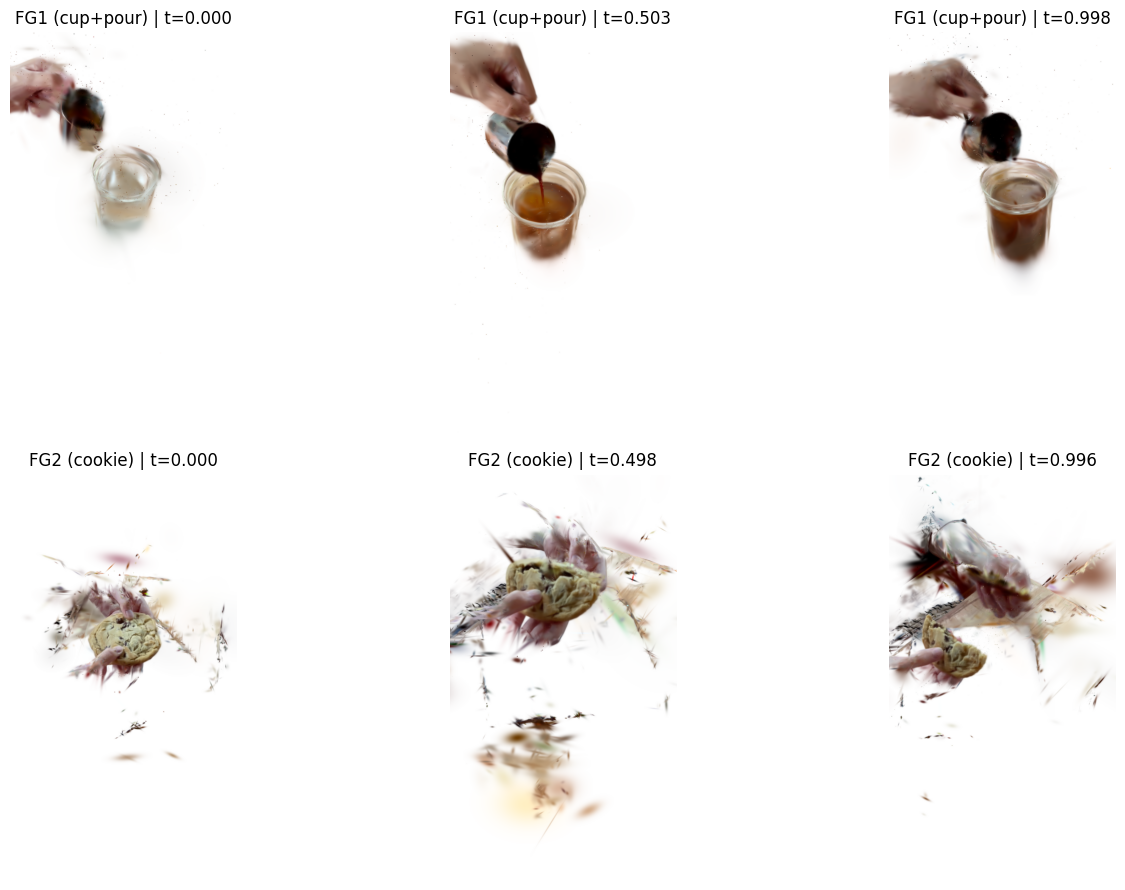


saved ./output/composite_oven_mitts_dark_americano_cookie_v01/fg_mask_sanity.png


In [40]:
def _report_and_fix_mask(name, g, scene_for_time):
    counts = g._mask_table.float().sum(dim=1).cpu().numpy()
    F_total = counts.shape[0]
    n_empty = int((counts == 0).sum())
    print(f'{name}: frames={F_total}, active per-frame  min={counts.min():.0f} mean={counts.mean():.0f} max={counts.max():.0f}, empty_frames={n_empty}')
    if n_empty == 0:
        return 0
    # Fill empty frames with the nearest non-empty frame's mask.
    nonempty_idx = np.where(counts > 0)[0]
    if nonempty_idx.size == 0:
        print(f'  WARNING: {name} mask is entirely empty — refusing to fix.')
        return 0
    fixed = 0
    for i in np.where(counts == 0)[0]:
        nearest = nonempty_idx[np.argmin(np.abs(nonempty_idx - i))]
        g._mask_table[i] = g._mask_table[nearest].clone()
        fixed += 1
    new_counts = g._mask_table.float().sum(dim=1).cpu().numpy()
    print(f'  filled {fixed} empty frames -> active per-frame  min={new_counts.min():.0f} mean={new_counts.mean():.0f} max={new_counts.max():.0f}')
    return fixed

n1_fix = _report_and_fix_mask('FG1 (cup+pour, americano)', g1, scene1)
n2_fix = _report_and_fix_mask('FG2 (cookie, split-cookie)', g2, scene2)

# Render FG1 alone in its native americano scene, FG2 alone in its native cookie scene.
# Use each scene's own train cameras so the mask alignment is exact (no reprojection).
fg1_train = scene1.getTrainCameras()
fg2_train = scene2.getTrainCameras()

# Pick 3 timestamps spanning each scene's training cameras.
def _three_views(cams):
    n = len(cams)
    return [cams[0], cams[n // 2], cams[n - 1]]

fg1_views = _three_views(fg1_train)
fg2_views = _three_views(fg2_train)

# Identity transforms for "FG-in-its-own-scene" rendering.
mb_id = torch.zeros(3); rb_id = torch.zeros(3)

# NOTE: pass bg=True with a single Gaussian set so the renderer treats `g1` as the
# scene-to-render. With bg=False + a single set, the function skips index 0 and crashes
# on `means3D_final = None`.
print('\nRendering FG1 alone (americano, white BG) at 3 viewpoints...')
fg1_imgs = []
with torch.no_grad():
    for v in fg1_views:
        r = render_compose(v, float(v.time), [g1], background,
                           motion_bias=[mb_id], rotation_bias=[rb_id], scales_bias=[1.0],
                           static=[False], seg=[True], bg=True)
        fg1_imgs.append((float(v.time), to8b(r['render']).transpose(1, 2, 0)))
print('Rendering FG2 alone (split-cookie, white BG) at 3 viewpoints...')
fg2_imgs = []
with torch.no_grad():
    for v in fg2_views:
        r = render_compose(v, float(v.time), [g2], background,
                           motion_bias=[mb_id], rotation_bias=[rb_id], scales_bias=[1.0],
                           static=[False], seg=[True], bg=True)
        fg2_imgs.append((float(v.time), to8b(r['render']).transpose(1, 2, 0)))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for col, (t, im) in enumerate(fg1_imgs):
    axes[0, col].imshow(im); axes[0, col].set_title(f'FG1 (cup+pour) | t={t:.3f}'); axes[0, col].axis('off')
for col, (t, im) in enumerate(fg2_imgs):
    axes[1, col].imshow(im); axes[1, col].set_title(f'FG2 (cookie) | t={t:.3f}'); axes[1, col].axis('off')
plt.tight_layout()
fg_mask_preview = os.path.join(RENDER_DIR, 'fg_mask_sanity.png')
os.makedirs(RENDER_DIR, exist_ok=True)
plt.savefig(fg_mask_preview, dpi=110, bbox_inches='tight')
plt.show()
print(f'\nsaved {fg_mask_preview}')

## 6. Initial transforms + single-frame composite

`scales_bias_X`, `rotation_bias_X` (rx, ry, rz radians, world axes), `motion_bias_X` (xyz, world). Index 0=BG, 1=FG1 (cup+pour), 2=FG2 (cookie). Tweak the FG1/FG2 values to land on the kitchen counter, then refine via the widgets below.

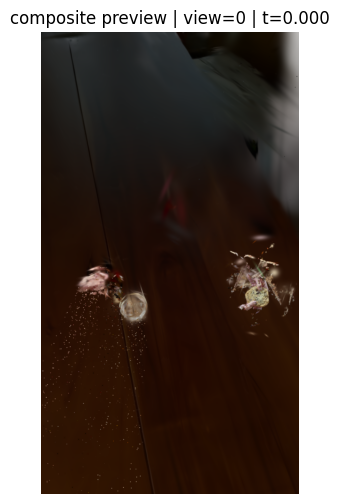

In [45]:
# Background (don't usually move).
scales_bias0   = 1.0
rotation_bias0 = torch.tensor([0.0, 0.0, 0.0])
motion_bias0   = torch.tensor([0.0, 0.0, 0.0])

# Seed values (scripts/seed_v11_video_path.py): we sample 8 frames along the BG video camera
# path, find the BG region that's central in at least half of them, and place each FG at the
# median of that region — separated by 2.5 units along the camera-averaged 'right' axis. This
# guarantees both objects stay on-screen for every frame of the mp4, not just the train views.
# Drag widgets in §7 to refine.
scales_bias1   = 0.265  # cup+pour: auto-fit to ~1.6 world units (smaller for visual separation)
rotation_bias1 = torch.tensor([0.0, 0.0, 0.0], device='cuda')
motion_bias1   = torch.tensor([-4.419,  2.624, 11.921], device='cuda')   # FG1 cup+pour, left

scales_bias2   = 0.269  # cookie: auto-fit to ~1.6 world units
rotation_bias2 = torch.tensor([0.0, 0.0, 0.0], device='cuda')
motion_bias2   = torch.tensor([-0.152,  1.608, 11.820], device='cuda')   # FG2 cookie, right (5 units away)

static_flags = [False, False, False]
seg_flags    = [USE_BG_DELETE_MASK, True, True]

train_cams0 = scene0.getTrainCameras()
VIEW_IDX = 0
test_view = train_cams0[VIEW_IDX]
timestamp = float(test_view.time)

with torch.no_grad():
    res = render_compose(
        test_view, timestamp, gaussians, background,
        motion_bias  = [motion_bias0, motion_bias1, motion_bias2],
        rotation_bias= [rotation_bias0, rotation_bias1, rotation_bias2],
        scales_bias  = [scales_bias0, scales_bias1, scales_bias2],
        static       = static_flags,
        seg          = seg_flags,
        bg           = True,
    )
plt.figure(figsize=(8, 6)); plt.imshow(to8b(res['render']).transpose(1, 2, 0))
plt.title(f'composite preview | view={VIEW_IDX} | t={timestamp:.3f}'); plt.axis('off'); plt.show()

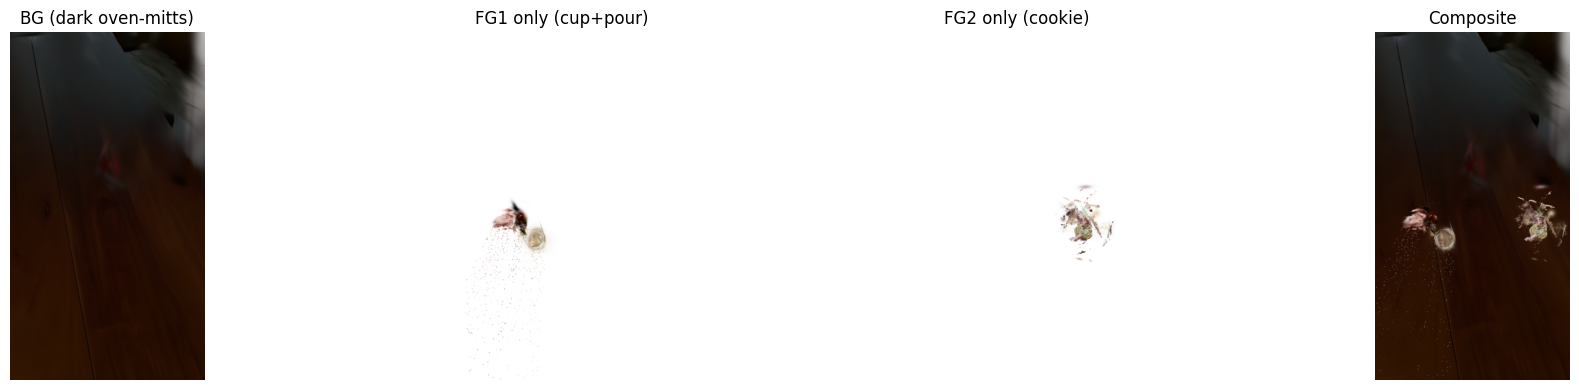

In [46]:
# Side-by-side: BG only / FG1 only / FG2 only / composite — useful while tuning.
with torch.no_grad():
    r_bg = render_compose(test_view, timestamp, [g0], background,
                          motion_bias=[motion_bias0], rotation_bias=[rotation_bias0],
                          scales_bias=[scales_bias0], static=[False], seg=[USE_BG_DELETE_MASK], bg=True)
    r_fg1 = render_compose(test_view, timestamp, [g0, g1], background,
                           motion_bias=[motion_bias0, motion_bias1], rotation_bias=[rotation_bias0, rotation_bias1],
                           scales_bias=[scales_bias0, scales_bias1], static=[False, False], seg=[USE_BG_DELETE_MASK, True], bg=False)
    r_fg2 = render_compose(test_view, timestamp, [g0, g2], background,
                           motion_bias=[motion_bias0, motion_bias2], rotation_bias=[rotation_bias0, rotation_bias2],
                           scales_bias=[scales_bias0, scales_bias2], static=[False, False], seg=[USE_BG_DELETE_MASK, True], bg=False)
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for a, im, t in zip(ax,
                    [to8b(r_bg['render']).transpose(1,2,0), to8b(r_fg1['render']).transpose(1,2,0),
                     to8b(r_fg2['render']).transpose(1,2,0), to8b(res['render']).transpose(1,2,0)],
                    ['BG (dark oven-mitts)', 'FG1 only (cup+pour)', 'FG2 only (cookie)', 'Composite']):
    a.imshow(im); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

## 7. Interactive widgets — tune each FG independently

Sliders write back to `motion_bias_X / rotation_bias_X / scales_bias_X / VIEW_IDX` so subsequent cells use the values you settled on. The translation sliders are camera-relative (`right / up / forward` from the current `VIEW_IDX`'s camera frame) for intuitive nudging; they accumulate on top of `base_offset_X`.

In [47]:
import torch.nn.functional as F
import ipywidgets as widgets
from IPython.display import display

def camera_axes_world(cam):
    W2C = cam.world_view_transform.cuda(); C2W = torch.inverse(W2C)
    right = C2W[:3, 0]; up = C2W[:3, 1]; forward = -C2W[:3, 2]
    return F.normalize(right, dim=0), F.normalize(up, dim=0), F.normalize(forward, dim=0)

n_views = len(train_cams0)
view_idx_w = widgets.IntSlider(value=0, min=0, max=max(0, n_views - 1), step=1, description='view', continuous_update=False)
time_w = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01, description='time', continuous_update=False)
quality_w = widgets.Dropdown(options=[('fast', 0.5), ('normal', 1.0)], value=1.0, description='quality')

def _make_panel(label, defaults):
    base_x = widgets.FloatSlider(value=defaults['base'][0], min=-15.0, max=15.0, step=0.05, description=f'{label} base_x')
    base_y = widgets.FloatSlider(value=defaults['base'][1], min=-15.0, max=15.0, step=0.05, description=f'{label} base_y')
    base_z = widgets.FloatSlider(value=defaults['base'][2], min=-15.0, max=15.0, step=0.05, description=f'{label} base_z')
    d_right = widgets.FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.02, description=f'{label} right')
    d_up = widgets.FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.02, description=f'{label} up')
    d_forward = widgets.FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.02, description=f'{label} fwd')
    scale = widgets.FloatSlider(value=defaults['scale'], min=0.05, max=3.0, step=0.01, description=f'{label} scale')
    rx = widgets.FloatSlider(value=defaults['rot'][0], min=-3.1416, max=3.1416, step=0.01, description=f'{label} rx')
    ry = widgets.FloatSlider(value=defaults['rot'][1], min=-3.1416, max=3.1416, step=0.01, description=f'{label} ry')
    rz = widgets.FloatSlider(value=defaults['rot'][2], min=-3.1416, max=3.1416, step=0.01, description=f'{label} rz')
    return dict(base_x=base_x, base_y=base_y, base_z=base_z,
                d_right=d_right, d_up=d_up, d_forward=d_forward,
                scale=scale, rx=rx, ry=ry, rz=rz)

p1 = _make_panel('FG1', {'base': [float(motion_bias1[0]), float(motion_bias1[1]), float(motion_bias1[2])],
                          'rot':  [0.0, 0.0, 0.0], 'scale': float(scales_bias1)})
p2 = _make_panel('FG2', {'base': [float(motion_bias2[0]), float(motion_bias2[1]), float(motion_bias2[2])],
                          'rot':  [0.0, 0.0, 0.0], 'scale': float(scales_bias2)})
out = widgets.Output()

def _redraw(*_):
    global VIEW_IDX, motion_bias1, rotation_bias1, scales_bias1, motion_bias2, rotation_bias2, scales_bias2, timestamp
    VIEW_IDX = int(view_idx_w.value)
    view = train_cams0[VIEW_IDX]
    timestamp = float(time_w.value)
    right, up, forward = camera_axes_world(view)
    def _resolve(p):
        base = torch.tensor([p['base_x'].value, p['base_y'].value, p['base_z'].value], device='cuda')
        m = base + p['d_right'].value * right + p['d_up'].value * up + p['d_forward'].value * forward
        r = torch.tensor([p['rx'].value, p['ry'].value, p['rz'].value], device='cuda')
        s = float(p['scale'].value)
        return m, r, s
    motion_bias1, rotation_bias1, scales_bias1 = _resolve(p1)
    motion_bias2, rotation_bias2, scales_bias2 = _resolve(p2)
    with out:
        out.clear_output(wait=True)
        with torch.no_grad():
            r = render_compose(view, timestamp, gaussians, background,
                motion_bias=[motion_bias0, motion_bias1, motion_bias2],
                rotation_bias=[rotation_bias0, rotation_bias1, rotation_bias2],
                scales_bias=[scales_bias0, scales_bias1, scales_bias2],
                static=static_flags, seg=seg_flags, bg=True,
                scaling_modifier=float(quality_w.value))
        plt.figure(figsize=(8, 6))
        plt.imshow(to8b(r['render']).transpose(1, 2, 0))
        plt.title(f'view={VIEW_IDX} | t={timestamp:.3f} | FG1 s={scales_bias1:.2f} m={motion_bias1.detach().cpu().tolist()}\nFG2 s={scales_bias2:.2f} m={motion_bias2.detach().cpu().tolist()}')
        plt.axis('off'); plt.show()

for w in [view_idx_w, time_w, quality_w]:
    w.observe(_redraw, names='value')
for d in (p1, p2):
    for w in d.values():
        w.observe(_redraw, names='value')

ui = widgets.VBox([
    widgets.HBox([view_idx_w, time_w, quality_w]),
    widgets.HTML('<b>FG1 (americano cup + pour)</b>'),
    widgets.HBox([p1['base_x'], p1['base_y'], p1['base_z']]),
    widgets.HBox([p1['d_right'], p1['d_up'], p1['d_forward']]),
    widgets.HBox([p1['scale'], p1['rx'], p1['ry'], p1['rz']]),
    widgets.HTML('<b>FG2 (split-cookie cookie)</b>'),
    widgets.HBox([p2['base_x'], p2['base_y'], p2['base_z']]),
    widgets.HBox([p2['d_right'], p2['d_up'], p2['d_forward']]),
    widgets.HBox([p2['scale'], p2['rx'], p2['ry'], p2['rz']]),
])
display(ui, out); _redraw()

Output()

## 8. Render the full mp4

Drives the BG (oven-mitts) video camera path. Each FG plays its own 4D dynamics in time-normalized [0,1] (cup pours, cookie breaks) — both 4D scenes get the BG's `viewpoint.time` value, which in HyperNeRF is normalized per-scene, so each FG sweeps through its motion in lockstep with the BG progress.

In [48]:
video_cams0 = scene0.getVideoCameras()
out_mp4 = os.path.join(RENDER_DIR, f'composite_{RUN_TAG}.mp4')
writer = imageio.get_writer(out_mp4, fps=30, quality=8)
torch.cuda.empty_cache(); gc.collect()
print(f'Rendering {len(video_cams0)} frames → {out_mp4}')
with torch.no_grad():
    for idx, viewpoint in enumerate(tqdm(video_cams0)):
        r = render_compose(viewpoint, viewpoint.time, gaussians, background,
            motion_bias=[motion_bias0, motion_bias1, motion_bias2],
            rotation_bias=[rotation_bias0, rotation_bias1, rotation_bias2],
            scales_bias=[scales_bias0, scales_bias1, scales_bias2],
            static=static_flags, seg=seg_flags, bg=True)
        writer.append_data(to8b(r['render']).transpose(1, 2, 0))
        del r
        if idx % 50 == 0: torch.cuda.empty_cache()
writer.close(); torch.cuda.empty_cache()
print(f'done → {out_mp4}')

Rendering 138 frames → ./output/composite_oven_mitts_dark_americano_cookie_v01/composite_oven_mitts_dark_americano_cookie_v01.mp4


  0%|          | 0/138 [00:00<?, ?it/s]IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (536, 960) to (544, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
556it [00:26, 21.07it/s]                         


done → ./output/composite_oven_mitts_dark_americano_cookie_v01/composite_oven_mitts_dark_americano_cookie_v01.mp4


## 9. Export composite PLY + insert mask for harmonization

Writes a PLY that concatenates:
- BG Gaussians (mitts opacity pushed to `-100` to hide them at render time);
- FG1 Gaussians (cup+pour) with `(scales_bias1, rotation_bias1, motion_bias1)` baked in;
- FG2 Gaussians (cookie) with `(scales_bias2, rotation_bias2, motion_bias2)` baked in.

Plus a `composite_inserted_*.pt` mask where `True` marks the inserted Gaussians (FG1 ∪ FG2) for every timestamp. This is what `pipeline/run_harmonize.py` and `pipeline/render_composite_harmonized_motion_video.py --composite_mode foreground_moves` consume.

**About 4D dynamics in the export**: the bake captures each FG's *canonical* (untransformed-by-deformation) Gaussians plus your `transform()` placement. The harmonization renderer above re-applies each Gaussian's deformation through the BG checkpoint's deformation MLP at `--composite_mode foreground_moves`. Because the FG Gaussians here come from americano/cookie checkpoints, they will deform under the *oven-mitts* MLP at render time, which is not exactly each FG's own MLP. For most short-time effects (pouring stream, cookie crack) this is acceptable; for higher-fidelity per-FG dynamics, render the per-frame snapshots in section 8 (already correct) and harmonize each frame independently — that's a larger change, ping me if you want it wired.

In [ ]:
from plyfile import PlyData, PlyElement

# Need a BG mask table to know which Gaussians to hide. If we don't have one, fabricate an all-keep table.
if not hasattr(g0, '_mask_table'):
    T = max(g1._mask_table.shape[0], g2._mask_table.shape[0])
    g0._mask_table = torch.ones((T, g0.get_xyz.shape[0]), dtype=torch.bool)
    g0._time_map = torch.linspace(0, 1, T)
    print(f'No BG mask table found — fabricated all-keep table of shape {tuple(g0._mask_table.shape)}.')

bg_keep_any = g0._mask_table.any(dim=0).bool()
fg1_keep_any = g1._mask_table.any(dim=0).bool()
fg2_keep_any = g2._mask_table.any(dim=0).bool()
N_bg, N_fg1, N_fg2 = int(g0._xyz.shape[0]), int(fg1_keep_any.sum()), int(fg2_keep_any.sum())

# BG arrays (full, with hidden mitts) ── opacity logits forced negative for removed Gaussians.
xyz_bg     = g0._xyz.detach()
fdc_bg     = g0._features_dc.detach()
frest_bg   = g0._features_rest.detach()
scaling_bg = g0._scaling.detach()
rotation_bg= g0._rotation.detach()
opacity_bg = g0._opacity.detach().clone()
opacity_bg[~bg_keep_any] = -100.0

def _bake_fg(g, keep, sb, rb, mb):
    with torch.no_grad():
        xyz_raw = g._xyz[keep].detach().clone()
        scl_act = g.scaling_activation(g._scaling[keep].detach().clone())
        rot_act = g.rotation_activation(g._rotation[keep].detach().clone())
        mb_d = mb.to('cuda') if not mb.is_cuda else mb
        rb_d = rb.to('cuda') if not rb.is_cuda else rb
        xyz_t, rot_t, scl_t = transform(xyz_raw, rot_act, scl_act, float(sb), mb_d, rb_d)
        return xyz_t, torch.log(scl_t.clamp(min=1e-8)), rot_t

xyz_fg1, scl_fg1, rot_fg1 = _bake_fg(g1, fg1_keep_any, scales_bias1, rotation_bias1, motion_bias1)
xyz_fg2, scl_fg2, rot_fg2 = _bake_fg(g2, fg2_keep_any, scales_bias2, rotation_bias2, motion_bias2)
fdc_fg1, frest_fg1, op_fg1 = g1._features_dc[fg1_keep_any].detach(), g1._features_rest[fg1_keep_any].detach(), g1._opacity[fg1_keep_any].detach()
fdc_fg2, frest_fg2, op_fg2 = g2._features_dc[fg2_keep_any].detach(), g2._features_rest[fg2_keep_any].detach(), g2._opacity[fg2_keep_any].detach()

xyz = torch.cat([xyz_bg, xyz_fg1.cuda(), xyz_fg2.cuda()], dim=0).cpu().numpy()
normals = np.zeros_like(xyz)
f_dc = torch.cat([fdc_bg.transpose(1,2).flatten(start_dim=1), fdc_fg1.transpose(1,2).flatten(start_dim=1), fdc_fg2.transpose(1,2).flatten(start_dim=1)], dim=0).cpu().numpy()
f_rest = torch.cat([frest_bg.transpose(1,2).flatten(start_dim=1), frest_fg1.transpose(1,2).flatten(start_dim=1), frest_fg2.transpose(1,2).flatten(start_dim=1)], dim=0).cpu().numpy()
opac = torch.cat([opacity_bg, op_fg1, op_fg2], dim=0).cpu().numpy()
scale = torch.cat([scaling_bg, scl_fg1.cuda(), scl_fg2.cuda()], dim=0).cpu().numpy()
rot = torch.cat([rotation_bg, rot_fg1.cuda(), rot_fg2.cuda()], dim=0).cpu().numpy()

dtype_full = [(a, 'f4') for a in g0.construct_list_of_attributes()]
elements = np.empty(xyz.shape[0], dtype=dtype_full)
attributes = np.concatenate((xyz, normals, f_dc, f_rest, opac, scale, rot), axis=1)
elements[:] = list(map(tuple, attributes))
os.makedirs(os.path.dirname(EXPORT_PLY_PATH), exist_ok=True)
PlyData([PlyElement.describe(elements, 'vertex')]).write(EXPORT_PLY_PATH)

T = int(g0._mask_table.shape[0]); N_total = int(xyz.shape[0])
inserted = torch.zeros((N_total,), dtype=torch.bool)
inserted[N_bg:] = True
mask_table = inserted.unsqueeze(0).repeat(T, 1)
payload = {
    'mask_table': mask_table,
    'time_map': g0._time_map,
    'note': f'inserted = FG1(americano cup+pour, {N_fg1} g) + FG2(cookie, {N_fg2} g)',
    'fg1_count': N_fg1, 'fg2_count': N_fg2, 'bg_count': N_bg,
    'bake_fg1': {'scale': float(scales_bias1), 'rot': rotation_bias1.detach().cpu().tolist(), 'motion': motion_bias1.detach().cpu().tolist()},
    'bake_fg2': {'scale': float(scales_bias2), 'rot': rotation_bias2.detach().cpu().tolist(), 'motion': motion_bias2.detach().cpu().tolist()},
}
os.makedirs(os.path.dirname(EXPORT_MASK_PATH), exist_ok=True)
torch.save(payload, EXPORT_MASK_PATH)

print(f'✓ Composite PLY  → {EXPORT_PLY_PATH}')
print(f'   N_bg={N_bg}, N_fg1={N_fg1}, N_fg2={N_fg2}, N_total={N_total}')
print(f'✓ Insert mask    → {EXPORT_MASK_PATH}  (shape={tuple(mask_table.shape)})')
print('\nNext: harmonize via pipeline (uses dark BG model + this composite PLY+mask):')
print('  python -m pipeline.run_harmonize \\')
print(f'    --model_path  {BG_MODEL_RENDER} \\')
print(f'    --source_path data/hypernerf/oven-mitts \\')
print(f'    --mask_path   {EXPORT_MASK_PATH} \\')
print(f'    --ply_path    {EXPORT_PLY_PATH} \\')
print(f'    --output_ply  {os.path.join(BG_MODEL_RENDER, "point_cloud/iteration_14000", f"harmonized_{EXPORT_TAG}.ply")} \\')
print(f'    --configs     {CFG_PATH} \\')
print('    --composite')